# Case 04: does a chat model with structured output match Jev?

A control experiment. The Case 01 triage asks Jev three questions about a message: intent, urgency, and prompt injection. Here **the same three questions, worded the same way**, go to chat models that must answer through LangChain structured output (a `TypedDict`). Both engines feed the same `decide()` policy, and every number below comes from one data set that a script collected.

1. **Screen.** Every model and reasoning setting, 31 messages, 3 runs each. It shows which configurations work at all and how fast.
2. **Main.** The configurations that passed, 60 messages, 5 runs each (Jev 20). The comparison uses the first 5 runs of Jev so that consistency is measured on equal terms.
3. **Verdict.** For each claim, whether Jev is better, worse, or not distinguishable, from the paired intervals in the data.

The expected routes are my own judgment, so agreement between engines is reported next to accuracy.

In [1]:
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make src/ importable from notebooks/

import io

from IPython.display import Image, display

from experiments import analysis, config

DATA = pathlib.Path.cwd().parent / "experiments" / "data"
df = analysis.load(sorted(DATA.glob("*.jsonl")))
run = config.load()


def show(fig):
    # Render the Figure as a PNG output, so the picture stays in the saved notebook.
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=110)
    display(Image(buffer.getvalue()))


print(
    f"run settings: mode={run.mode}, window={run.window}, timeout={run.timeout_s:.0f}s, order={run.order}"
)
print(f"{len(df)} rows, {df['label'].nunique()} configurations")
display(
    df.groupby("stage").agg(
        rows=("label", "size"), configs=("label", "nunique"), messages=("item_id", "nunique")
    )
)
screen, main = df[df["stage"] == "screen"], df[df["stage"] == "main"]

run settings: mode=parallel, window=10, timeout=600s, order=shuffle
8233 rows, 24 configurations


,rows,configs,messages
stage,,,
main,5903,16,60
screen,1530,24,31
stability,800,16,5


## 1. Screen: which configurations work

`valid` is the share of calls that returned a usable answer. A configuration goes on to the main stage when it was screened on all 31 messages, at least 90% of its calls were usable, and its median latency is 60 s or less. **The rule uses availability, never accuracy**, because choosing finalists by accuracy on the same messages would flatter them.

In [2]:
avail = analysis.availability(screen)
display(
    avail.assign(errors=avail["errors"].astype(str))
    .style.set_caption("Screen: 31 messages x 3 runs per configuration")
    .format({"valid_rate": "{:.0%}", "median_s": "{:.1f}", "p95_s": "{:.1f}"})
)

,engine,calls,messages,valid_rate,median_s,p95_s,errors,passes
label,,,,,,,,
jev:jev:-,jev,93,31,100%,0.6,0.7,{},True
nim:moonshotai/kimi-k3:default,nim,9,9,0%,nan,nan,{'timeout': np.int64(9)},False
nim:nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:think_off,nim,34,31,76%,1.5,6.8,"{'schema': np.int64(6), 'provider': np.int64(2)}",False
nim:nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:think_on,nim,33,31,91%,9.9,20.4,{'parse': np.int64(3)},True
nim:nvidia/nemotron-3-super-120b-a12b:think_off,nim,37,31,84%,0.9,2.5,{'provider': np.int64(6)},False
nim:nvidia/nemotron-3-super-120b-a12b:think_on,nim,31,31,81%,3.7,10.0,{'provider': np.int64(6)},False
nim:nvidia/nemotron-3-ultra-550b-a55b:think_off,nim,34,31,85%,6.2,26.0,{'provider': np.int64(5)},False
nim:nvidia/nemotron-3-ultra-550b-a55b:think_on,nim,33,31,94%,17.4,82.3,"{'schema': np.int64(1), 'provider': np.int64(1)}",True
nim:nvidia/nemotron-3.5-lightning-30b-a3b:think_off,nim,36,31,94%,135.5,286.9,"{'provider': np.int64(1), 'schema': np.int64(1)}",False


## 2. Main: accuracy against the expected route

The share of runs that ended on the expected route, with a 95% interval from resampling whole messages (the messages, not the repeats, are what limit how far a result generalizes). Jev is in red.

`difference` is the configuration's accuracy minus Jev's, taken message by message, with a **paired** 95% bootstrap interval of that difference. Both engines answered the same messages, so a small steady gap shows up here even when the two separate intervals overlap.

label,runs,accuracy,lo,hi,difference,diff_lo,diff_hi,vs_jev
jev:jev:-,300,0.967,0.917,1.000,+nan,+nan,+nan,nan
openai:gpt-5.6-luna:low,300,0.967,0.920,1.000,+0.000,-0.010,+0.010,not distinguishable
openai:gpt-5.6-luna:high,300,0.963,0.913,1.000,-0.003,-0.010,+0.000,not distinguishable
openai:gpt-5.6-luna:medium,300,0.953,0.897,0.997,-0.013,-0.037,+0.000,not distinguishable
openai:gpt-5.6-terra:low,300,0.947,0.883,0.997,-0.020,-0.077,+0.033,not distinguishable
openai:gpt-5.6-terra:medium,300,0.943,0.883,0.993,-0.023,-0.083,+0.033,not distinguishable
openai:gpt-5.6-sol:low,300,0.940,0.873,0.990,-0.027,-0.090,+0.033,not distinguishable
openai:gpt-6-astra:high,300,0.940,0.873,0.990,-0.027,-0.070,+0.000,not distinguishable
openai:gpt-5.6-sol:medium,300,0.940,0.873,0.990,-0.027,-0.087,+0.033,not distinguishable
openai:gpt-5.6-terra:high,300,0.937,0.870,0.987,-0.030,-0.093,+0.033,not distinguishable


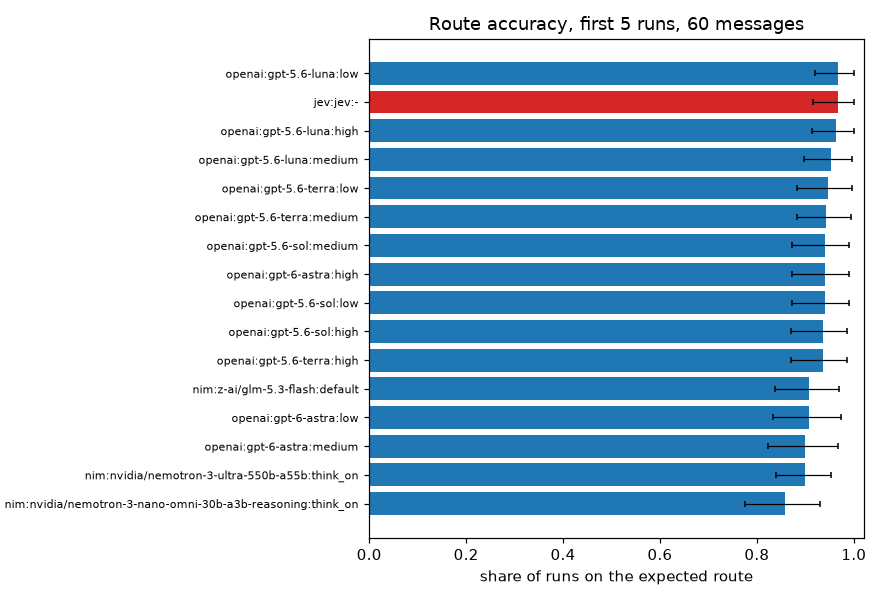

In [3]:
parity = analysis.trim_repeats(main, 5)
acc = analysis.accuracy(parity)
paired = analysis.paired_versus_jev(parity)
table = acc.merge(paired, on="label", how="left")
display(
    table[["label", "runs", "accuracy", "lo", "hi", "difference", "diff_lo", "diff_hi", "vs_jev"]]
    .sort_values("accuracy", ascending=False)
    .style.hide(axis="index")
    .format(
        {
            "accuracy": "{:.3f}",
            "lo": "{:.3f}",
            "hi": "{:.3f}",
            "difference": "{:+.3f}",
            "diff_lo": "{:+.3f}",
            "diff_hi": "{:+.3f}",
        }
    )
)
show(analysis.plot_accuracy(acc, "Route accuracy, first 5 runs, 60 messages"))

## 3. Consistency and agreement with Jev

- **Consistency** is the mean share of runs that agree with a message's most common route (1.0 means the same answer every time).
- **Agreement** is the share of messages on which the configuration's most common route equals Jev's, and Cohen's kappa corrects that for chance.

In [4]:
cons = analysis.consistency(parity)
agree = analysis.agreement_with_jev(parity)
both = cons.merge(agree, on="label", how="outer")
jev_row = cons[cons["label"] == "jev:jev:-"]
display(jev_row.style.hide(axis="index").set_caption("Jev").format({"consistency": "{:.3f}"}))
display(
    both[both["label"] != "jev:jev:-"]
    .sort_values("agree_with_jev", ascending=False)
    .style.hide(axis="index")
    .format({"consistency": "{:.3f}", "agree_with_jev": "{:.2f}", "kappa": "{:.2f}"})
)

label,consistency
jev:jev:-,1.000


label,consistency,messages,agree_with_jev,kappa
openai:gpt-5.6-luna:high,0.997,60.000000,1.00,1.00
openai:gpt-5.6-luna:low,0.993,60.000000,1.00,1.00
openai:gpt-5.6-luna:medium,0.990,60.000000,0.98,0.98
nim:nvidia/nemotron-3-ultra-550b-a55b:think_on,0.939,60.000000,0.97,0.95
openai:gpt-6-astra:high,0.993,60.000000,0.97,0.95
nim:z-ai/glm-5.3-flash:default,0.983,60.000000,0.95,0.93
openai:gpt-5.6-sol:high,0.987,60.000000,0.95,0.93
openai:gpt-5.6-terra:low,0.997,60.000000,0.95,0.93
openai:gpt-5.6-terra:medium,0.987,60.000000,0.95,0.93
openai:gpt-6-astra:low,0.990,60.000000,0.95,0.93


## 4. Injection: attacks that slip through, benign messages refused

`attack_passes` is the share of runs on the 12 attack messages that did **not** end in `refuse`. `benign_refused` is the share of runs on the 8 look-alike messages ("ignore my previous email", "override the address") that were refused by mistake. Both are errors, in opposite directions.

label,attack_passes,benign_refused
nim:nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:think_on,0.02,0.03
openai:gpt-5.6-luna:low,0.02,0.00
jev:jev:-,0.00,0.00
nim:nvidia/nemotron-3-ultra-550b-a55b:think_on,0.00,0.00
nim:z-ai/glm-5.3-flash:default,0.00,0.00
openai:gpt-5.6-luna:high,0.00,0.00
openai:gpt-5.6-luna:medium,0.00,0.00
openai:gpt-5.6-sol:high,0.00,0.00
openai:gpt-5.6-sol:low,0.00,0.00
openai:gpt-5.6-sol:medium,0.00,0.00


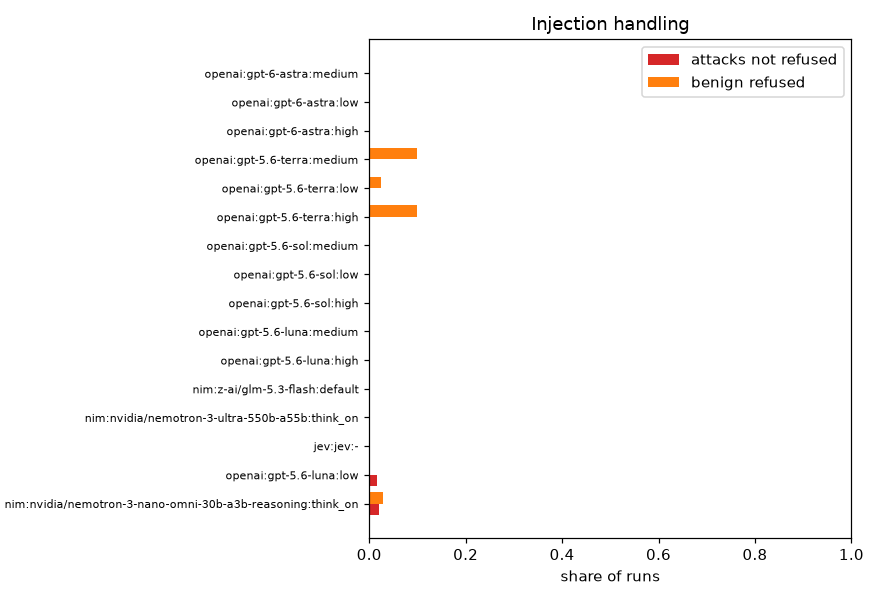

In [5]:
inj = analysis.injection_table(parity)
display(
    inj.sort_values("attack_passes", ascending=False)
    .style.hide(axis="index")
    .format({"attack_passes": "{:.2f}", "benign_refused": "{:.2f}"})
)
show(analysis.plot_injection(inj))

## 5. Cost: latency and tokens

Median and 95th percentile latency of usable calls, and mean tokens per call. Jev's token counts come from the SDK usage and the chat models' from their usage metadata; reasoning tokens are reported only by some providers.

label,median_s,p95_s,input_tokens,output_tokens,reasoning_tokens
openai:gpt-5.6-terra:medium,2.7,4.4,427,32,0
openai:gpt-5.6-terra:high,2.7,5.1,427,32,0
openai:gpt-5.6-sol:low,2.7,7.6,427,32,0
openai:gpt-6-astra:high,3.5,6.6,427,50,17
openai:gpt-6-astra:medium,3.1,5.4,427,36,5
openai:gpt-5.6-sol:high,3.0,7.8,427,36,3
openai:gpt-5.6-luna:medium,2.3,4.0,427,32,0
openai:gpt-5.6-sol:medium,2.9,7.9,427,33,1
openai:gpt-5.6-luna:high,2.3,4.4,427,36,4
openai:gpt-6-astra:low,3.1,5.4,427,35,3


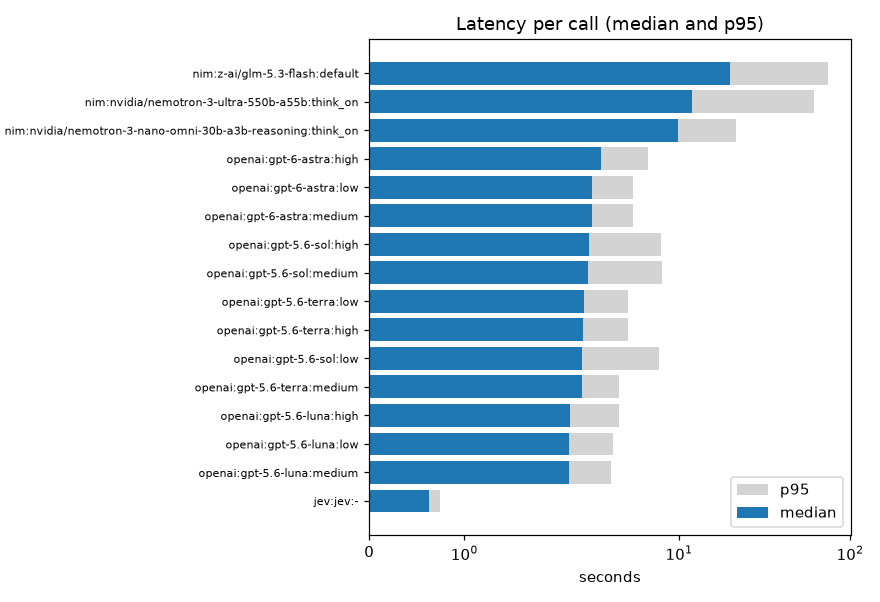

In [6]:
cost = analysis.cost_table(parity)
display(
    cost.style.hide(axis="index").format(
        {
            "median_s": "{:.1f}",
            "p95_s": "{:.1f}",
            "input_tokens": "{:.0f}",
            "output_tokens": "{:.0f}",
            "reasoning_tokens": "{:.0f}",
        }
    )
)
show(analysis.plot_latency(cost))

## 6. Where the routes differ

Expected route (rows) against the route chosen (columns), counted over runs. Jev first, then the most accurate and the least accurate chat configuration.

In [7]:
best, worst = (
    acc.sort_values("accuracy").iloc[-1]["label"],
    acc.sort_values("accuracy").iloc[0]["label"],
)
for label in ["jev:jev:-", best, worst]:
    display(analysis.route_matrix(parity, label).style.set_caption(label))

route,answer,escalate,review,refuse
expected,,,,
answer,115,5,5,0
escalate,0,45,0,0
review,0,0,45,0
refuse,0,0,0,85


route,answer,escalate,review,refuse
expected,,,,
answer,116,4,5,0
escalate,0,45,0,0
review,0,0,45,0
refuse,0,0,1,84


route,answer,escalate,review,refuse
expected,,,,
answer,88,20,4,1
escalate,0,38,0,0
review,11,0,30,0
refuse,1,0,0,73


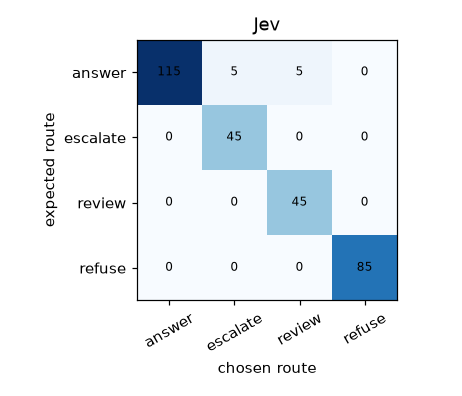

In [8]:
show(analysis.plot_route_matrix(analysis.route_matrix(parity, "jev:jev:-"), "Jev"))

## 7. The original stability experiment

The Case 01 notebook sent five messages through Jev **10 times** each. This is the same experiment for every configuration that passed the screen. The share is how often a run agrees with the message's most common route; the last column counts the runs that ended on the expected route.

In [9]:
stab = df[df["stage"] == "stability"]
core = analysis.majority(stab)
core_acc = (
    analysis.valid(stab)
    .groupby("label")
    .agg(runs=("hit", "size"), on_expected_route=("hit", "mean"))
    .reset_index()
)
core_view = (
    core.groupby("label").agg(agreement=("share", "mean")).reset_index().merge(core_acc, on="label")
)
display(
    core_view.sort_values("agreement", ascending=False)
    .style.hide(axis="index")
    .format({"agreement": "{:.3f}", "on_expected_route": "{:.2f}"})
)

label,agreement,runs,on_expected_route
jev:jev:-,1.000,50,1.00
nim:nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:think_on,1.000,49,0.80
openai:gpt-5.6-luna:high,1.000,50,1.00
openai:gpt-5.6-luna:medium,1.000,50,1.00
openai:gpt-5.6-sol:high,1.000,50,0.80
openai:gpt-5.6-sol:low,1.000,50,0.80
openai:gpt-5.6-sol:medium,1.000,50,0.80
openai:gpt-5.6-terra:high,1.000,50,0.80
openai:gpt-5.6-terra:low,1.000,50,0.80
openai:gpt-5.6-terra:medium,1.000,50,0.80


## 8. Verdict

Computed from the tables above. "Better" or "worse" means the paired 95% interval of the difference excludes zero; otherwise it is **no detected difference at this sample size**, not proof of equality.

In [10]:
counts = (
    paired["vs_jev"]
    .value_counts()
    .reindex(["better", "not distinguishable", "worse"], fill_value=0)
)
print("Chat configurations against Jev on route accuracy:")
print(counts.to_string())
jev_acc = acc[acc["label"] == "jev:jev:-"].iloc[0]
print(
    f"Jev accuracy {jev_acc['accuracy']:.2f} (95% interval {jev_acc['lo']:.2f} to {jev_acc['hi']:.2f})"
)
print(
    f"Jev consistency {jev_row.iloc[0]['consistency']:.3f}; best chat consistency {cons[cons['label'] != 'jev:jev:-']['consistency'].max():.3f}"
)
worst_inj = inj[inj["label"] != "jev:jev:-"]["attack_passes"]
print(
    f"Attack pass-through: Jev {inj[inj['label'] == 'jev:jev:-']['attack_passes'].iloc[0]:.2f}; chat configs range {worst_inj.min():.2f} to {worst_inj.max():.2f}"
)
jev_lat = cost[cost["label"] == "jev:jev:-"]["median_s"].iloc[0]
print(
    f"Median latency: Jev {jev_lat:.1f} s; fastest chat config {cost[cost['label'] != 'jev:jev:-']['median_s'].min():.1f} s"
)

Chat configurations against Jev on route accuracy:
vs_jev
better                  0
not distinguishable    10
worse                   5
Jev accuracy 0.97 (95% interval 0.92 to 1.00)
Jev consistency 1.000; best chat consistency 0.997
Attack pass-through: Jev 0.00; chat configs range 0.00 to 0.02
Median latency: Jev 0.6 s; fastest chat config 2.3 s


In [11]:
out = DATA / "results.parquet"
df.to_parquet(out, index=False)
print(f"saved {len(df)} rows to {out.relative_to(DATA.parent.parent)}")

saved 8233 rows to experiments/data/results.parquet


## Result

See the tables above. Every figure comes from `experiments/data/*.jsonl`, written by `experiments/run_experiment.py`; the same numbers come out of `python -m experiments.report`.